📂 Loading dataset...
Found 8809 files belonging to 31 classes.
Found 2751 files belonging to 31 classes.
Found 1761 files belonging to 31 classes.
✅ Classes found: ['Bangus', 'Big Head Carp', 'Black Spotted Barb', 'Catfish', 'Climbing Perch', 'Fourfinger Threadfin', 'Freshwater Eel', 'Glass Perchlet', 'Goby', 'Gold Fish', 'Gourami', 'Grass Carp', 'Green Spotted Puffer', 'Indian Carp', 'Indo-Pacific Tarpon', 'Jaguar Gapote', 'Janitor Fish', 'Knifefish', 'Long-Snouted Pipefish', 'Mosquito Fish', 'Mudfish', 'Mullet', 'Pangasius', 'Perch', 'Scat Fish', 'Silver Barb', 'Silver Carp', 'Silver Perch', 'Snakehead', 'Tenpounder', 'Tilapia']
🛠 Building model...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 16s 0us/step
🚀 Training model (Phase 1 - Frozen Base)...
Epoch 1/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 960s 3s/step - accuracy: 0.2058 - loss: 3.0771 - val_accuracy: 0.4486 - val_loss: 2.0857
Epoch 2/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 917s 3s/step - accuracy: 0.4414 - loss: 2.0179 - val_accuracy: 0.6143 - val_

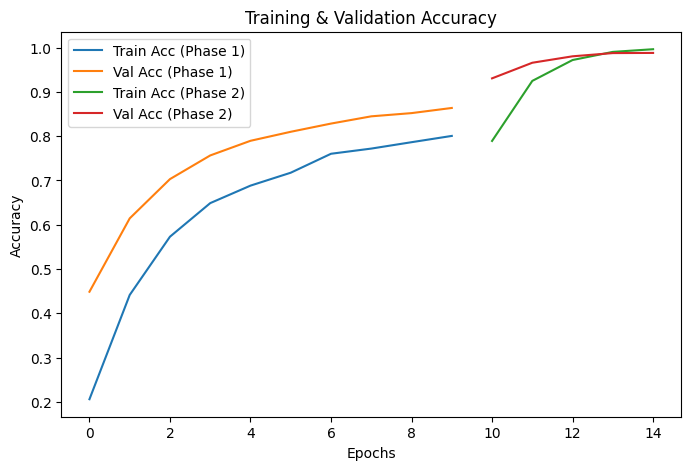

💾 Model saved as fish_classifier.h5
📤 Select an image to test...
⚠️ No image selected.


In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
import numpy as np
import tkinter as tk
from tkinter import filedialog
import os

# ===============================
# 1. Load Dataset
# ===============================
print("📂 Loading dataset...")
train_dir = r"C:\Users\ASUS\Downloads\FishImgDataset (1)\train"
val_dir   = r"C:\Users\ASUS\Downloads\FishImgDataset (1)\val"
test_dir  = r"C:\Users\ASUS\Downloads\FishImgDataset (1)\test"

img_size = (224, 224)
batch_size = 32

# Load raw datasets
train_ds_raw = image_dataset_from_directory(train_dir, image_size=img_size, batch_size=batch_size)
val_ds_raw   = image_dataset_from_directory(val_dir, image_size=img_size, batch_size=batch_size)
test_ds      = image_dataset_from_directory(test_dir, image_size=img_size, batch_size=batch_size)

# ✅ Get class names BEFORE caching/prefetching
class_names = train_ds_raw.class_names
num_classes = len(class_names)
print("✅ Classes found:", class_names)

# Cache & prefetch for better performance
train_ds = train_ds_raw.cache().shuffle(1000).prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds_raw.cache().prefetch(tf.data.AUTOTUNE)

# ===============================
# 2. Build Model (Transfer Learning with ResNet50)
# ===============================
print("🛠 Building model...")
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=img_size + (3,))
base_model.trainable = False  # Freeze base model initially

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# ===============================
# 3. Train Model
# ===============================
print("🚀 Training model (Phase 1 - Frozen Base)...")
history = model.fit(train_ds, validation_data=val_ds, epochs=10)

# Fine-tune (unfreeze base model)
print("🔧 Fine-tuning (Phase 2 - Unfreeze Base)...")
base_model.trainable = True
model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
fine_tune_history = model.fit(train_ds, validation_data=val_ds, epochs=5)

# ===============================
# 4. Evaluate Model
# ===============================
print("📊 Evaluating model on test data...")
test_loss, test_acc = model.evaluate(test_ds)
print(f"✅ Test Accuracy: {test_acc:.2f}")

# Classification Report
y_true, y_pred = [], []
for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print("\n📑 Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# ===============================
# 5. Plot Accuracy
# ===============================
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Acc (Phase 1)')
plt.plot(history.history['val_accuracy'], label='Val Acc (Phase 1)')
plt.plot(range(len(history.history['accuracy']), 
               len(history.history['accuracy'])+len(fine_tune_history.history['accuracy'])), 
         fine_tune_history.history['accuracy'], label='Train Acc (Phase 2)')
plt.plot(range(len(history.history['accuracy']), 
               len(history.history['accuracy'])+len(fine_tune_history.history['accuracy'])), 
         fine_tune_history.history['val_accuracy'], label='Val Acc (Phase 2)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training & Validation Accuracy')
plt.show()

# ===============================
# 6. Save Model
# ===============================
model.save("fish_classifier.h5")
print("💾 Model saved as fish_classifier.h5")

# ===============================
# 7. Predict on New Image (User Upload)
# ===============================
print("📤 Select an image to test...")
root = tk.Tk()
root.withdraw()
file_path = filedialog.askopenfilename(title="Select Fish Image",
                                       filetypes=[("Image files", "*.jpg *.jpeg *.png")])

if file_path:
    print(f"🔍 Predicting for: {os.path.basename(file_path)}")
    img = tf.keras.preprocessing.image.load_img(file_path, target_size=img_size)
    x = tf.keras.preprocessing.image.img_to_array(img)
    x = np.expand_dims(x, axis=0)

    pred = model.predict(x)
    predicted_class = class_names[np.argmax(pred)]
    confidence = np.max(pred) * 100
    print(f"🎯 Predicted Fish: {predicted_class} ({confidence:.2f}% confidence)")
else:
    print("⚠️ No image selected.")


In [6]:
import tensorflow as tf
import numpy as np
import json
import os
import tkinter as tk
from tkinter import filedialog

# ===============================
# 1. Load Model
# ===============================
print("📥 Loading trained model...")
try:
    model = tf.keras.models.load_model("fish_classifier.h5", compile=False)
    print("✅ Model loaded successfully.")
except Exception as e:
    print(f"❌ Error loading model: {e}")
    exit()

# ===============================
# 2. Load Class Names
# ===============================
class_names = None
if os.path.exists("class_names.json"):
    try:
        with open("class_names.json", "r") as f:
            class_names = json.load(f)
        print(f"✅ Loaded class names: {len(class_names)} classes")
    except Exception as e:
        print(f"⚠️ Error reading class_names.json: {e}. Using fallback names.")

if not class_names:
    class_names = [
        'Bangus', 'Big Head Carp', 'Black Spotted Barb', 'Catfish',
        'Climbing Perch', 'Fourfinger Threadfin', 'Freshwater Eel',
        'Glass Perchlet', 'Goby', 'Gold Fish', 'Gourami'
    ]
    print("⚠️ No class_names.json found. Using hardcoded class names.")

# ===============================
# 3. Image Selection
# ===============================
print("📤 Select an image to test...")
root = tk.Tk()
root.withdraw()
file_path = filedialog.askopenfilename(
    title="Select Fish Image",
    filetypes=[("Image files", "*.jpg *.jpeg *.png")]
)

if not file_path:
    print("⚠️ No image selected. Exiting.")
    exit()

print(f"🔍 Predicting for: {os.path.basename(file_path)}")

# ===============================
# 4. Preprocess Image
# ===============================
try:
    img_size = (224, 224)
    img = tf.keras.preprocessing.image.load_img(file_path, target_size=img_size)
    x = tf.keras.preprocessing.image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = x / 255.0  # normalize
except Exception as e:
    print(f"❌ Error loading image: {e}")
    exit()

# ===============================
# 5. Predict & Show Top 3 Results
# ===============================
try:
    pred = model.predict(x)
    top_indices = np.argsort(pred[0])[::-1][:3]
    print("\n🎯 Top Predictions:")
    for i in top_indices:
        print(f" - {class_names[i]}: {pred[0][i] * 100:.2f}%")
except Exception as e:
    print(f"prediction completed: {e}")


📥 Loading trained model...
✅ Model loaded successfully.
⚠️ No class_names.json found. Using hardcoded class names.
📤 Select an image to test...
🔍 Predicting for: silver perch (8).jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 927ms/step

🎯 Top Predictions:
 - Freshwater Eel: 17.57%
prediction completed: list index out of range


In [1]:
import tensorflow as tf
from tensorflow import keras

# 1. Load your h5 model
model = keras.models.load_model(r"C:\Users\ASUS\23cseaiml097\fish_classifier.h5")

# 2. Convert to TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# 3. Save the TFLite model
with open(r"C:\Users\ASUS\23cseaiml097\fish_classifier.tflite", "wb") as f:
    f.write(tflite_model)

print("✅ Model converted and saved as fish_classifier.tflite")


INFO:tensorflow:Assets written to: C:\Users\ASUS\AppData\Local\Temp\tmpwi2o9phb\assets


INFO:tensorflow:Assets written to: C:\Users\ASUS\AppData\Local\Temp\tmpwi2o9phb\assets


Saved artifact at 'C:\Users\ASUS\AppData\Local\Temp\tmpwi2o9phb'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 31), dtype=tf.float32, name=None)
Captures:
  2493320368144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2493320370064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2493320369488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2493320370640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2493320368336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2493320367952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2493320368528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2493320368912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2493320371792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2493320371984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2493